In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("meowmeowmeowmeowmeow/gtsrb-german-traffic-sign")

print("Path to dataset files:", path)

100%|██████████| 612M/612M [00:06<00:00, 106MB/s] 

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/meowmeowmeowmeowmeow/gtsrb-german-traffic-sign/versions/1


In [2]:
import kagglehub
import shutil
import os

# Download the dataset (this will download to Kaggle's cache location)
#download_path = kagglehub.dataset_download("meowmeowmeowmeowmeow/gtsrb-german-traffic-sign")

# Define your external directory path
external_dir = "GTSRB_Directory"  # Replace with your actual path

# Create the directory if it doesn't exist
os.makedirs(external_dir, exist_ok=True)

# Move or copy the files to your external directory
# Option 1: If it's a single file (like a zip)
if os.path.isfile(path):
    shutil.copy(path, external_dir)
    print(f"File copied to: {external_dir}")

# Option 2: If it's a directory of files
elif os.path.isdir(path):
    for item in os.listdir(path):
        src = os.path.join(path, item)
        dst = os.path.join(external_dir, item)
        if os.path.isdir(src):
            shutil.copytree(src, dst)
        else:
            shutil.copy2(src, dst)
    print(f"All files copied to: {external_dir}")

print("Download complete and saved to external directory")

All files copied to: GTSRB_Directory
Download complete and saved to external directory


In [3]:
import os

test_dir = 'GTSRB_Directory/Test'
num_test_samples = len([f for f in os.listdir(test_dir) if f.endswith(('.ppm', '.png', '.jpg'))])
print(f"Number of test samples: {num_test_samples}")

Number of test samples: 12630


In [4]:
import pandas as pd

# Load the Test.csv file
test_df = pd.read_csv('GTSRB_Directory/Test.csv')

# Number of test samples = number of rows in the dataframe
num_test_samples = len(test_df)
print(f"Number of test samples: {num_test_samples}")

Number of test samples: 12630


In [5]:
import shutil
import os

# Define paths
source_dir = "GTSRB_Directory"  # Path to your downloaded GTSRB dataset
external_dir = "Test_subset"  # Replace with your target directory (e.g., "D:/TrafficSignData")

# Ensure the external directory exists
os.makedirs(external_dir, exist_ok=True)

# Copy Test.csv
shutil.copy2(os.path.join(source_dir, "Test.csv"), external_dir)

# Copy the entire Test directory
test_source = os.path.join(source_dir, "Test")
test_destination = os.path.join(external_dir, "Test")

if os.path.exists(test_destination):
    shutil.rmtree(test_destination)  # Remove if already exists (optional)

shutil.copytree(test_source, test_destination)

print(f"Test directory and Test.csv successfully copied to: {external_dir}")

Test directory and Test.csv successfully copied to: Test_subset


In [6]:
import os
import pandas as pd

# Path to the external directory where you saved Test and Test.csv
external_dir = "/content/Test_subset"  # Replace with your actual path

# --- Count samples in Test.csv ---
test_csv_path = os.path.join(external_dir, "Test.csv")
if os.path.exists(test_csv_path):
    test_df = pd.read_csv(test_csv_path)
    num_csv_samples = len(test_df)
    print(f"Number of samples in Test.csv: {num_csv_samples}")
else:
    print("Test.csv not found in the external directory.")

# --- Count image files in the Test directory ---
test_dir = os.path.join(external_dir, "Test")
if os.path.exists(test_dir):
    # List all image files (supports .ppm, .png, .jpg)
    image_files = [f for f in os.listdir(test_dir) if f.lower().endswith(('.ppm', '.png', '.jpg'))]
    num_image_samples = len(image_files)
    print(f"Number of image files in Test/: {num_image_samples}")
else:
    print("Test/ directory not found in the external directory.")

# --- Verify consistency ---
if 'num_csv_samples' in locals() and 'num_image_samples' in locals():
    if num_csv_samples == num_image_samples:
        print("✅ Test.csv and Test/ counts match!")
    else:
        print("⚠️ Mismatch: Test.csv and Test/ counts differ.")

Number of samples in Test.csv: 12630
Number of image files in Test/: 12630
✅ Test.csv and Test/ counts match!


In [10]:
import pandas as pd
import os
import shutil

# Define paths (UPDATE THESE!)
base_dir = "/content/Test_subset"  # Directory where 'Test/' and 'Test.csv' are stored
test_csv_path = os.path.join(base_dir, "Test.csv")
test_images_dir = os.path.join(base_dir, "Test")
attack_data_dir = os.path.join(base_dir, "Attack_testdata")

# Create target directory
os.makedirs(attack_data_dir, exist_ok=True)

# Load CSV and clean paths
test_df = pd.read_csv(test_csv_path)
test_df["Path"] = test_df["Path"].str.replace("Test/", "")  # Fix path format

# Sample 12 images per class
samples_per_class = 12
subset_entries = []

for class_id, group in test_df.groupby("ClassId"):
    sampled = group.sample(n=min(samples_per_class, len(group)), random_state=42)
    subset_entries.append(sampled)

    # Copy images
    for _, row in sampled.iterrows():
        src_path = os.path.join(test_images_dir, row["Path"])
        dst_path = os.path.join(attack_data_dir, os.path.basename(row["Path"]))
        shutil.copy2(src_path, dst_path)

# Save subset metadata
subset_df = pd.concat(subset_entries)
subset_df.to_csv(os.path.join(attack_data_dir, "Attack_Test.csv"), index=False)

# Verify
print(f"Subset created in: {attack_data_dir}")
print("Samples per class:")
print(subset_df["ClassId"].value_counts().sort_index())

Subset created in: /content/Test_subset/Attack_testdata
Samples per class:
ClassId
0     12
1     12
2     12
3     12
4     12
5     12
6     12
7     12
8     12
9     12
10    12
11    12
12    12
13    12
14    12
15    12
16    12
17    12
18    12
19    12
20    12
21    12
22    12
23    12
24    12
25    12
26    12
27    12
28    12
29    12
30    12
31    12
32    12
33    12
34    12
35    12
36    12
37    12
38    12
39    12
40    12
41    12
42    12
Name: count, dtype: int64


In [22]:
import pandas as pd
import os

# Path to your subset metadata
attack_data_dir = "/content/Test_subset/Attack_testdata"  # Update this!
subset_csv_path = os.path.join(attack_data_dir, "Attack_Test.csv")

# Load subset metadata
subset_df = pd.read_csv(subset_csv_path)

# Get first 2 class IDs (sorted)
first_two_classes = sorted(subset_df["ClassId"].unique())[0:2]

# Print 12 images from each of the first 2 classes
for class_id in first_two_classes:
    print(f"\nClass {class_id} samples:")
    class_samples = subset_df[subset_df["ClassId"] == class_id]["Path"].head(12)

    for i, path in enumerate(class_samples, 1):
        print(f"{i}. {os.path.basename(path)}")


Class 0 samples:
1. 00243.png
2. 00778.png
3. 04726.png
4. 06854.png
5. 02045.png
6. 11771.png
7. 04512.png
8. 09117.png
9. 01853.png
10. 11812.png
11. 06946.png
12. 10381.png

Class 1 samples:
1. 05687.png
2. 04759.png
3. 00880.png
4. 03331.png
5. 07570.png
6. 01029.png
7. 01001.png
8. 02663.png
9. 04864.png
10. 06484.png
11. 12383.png
12. 07517.png


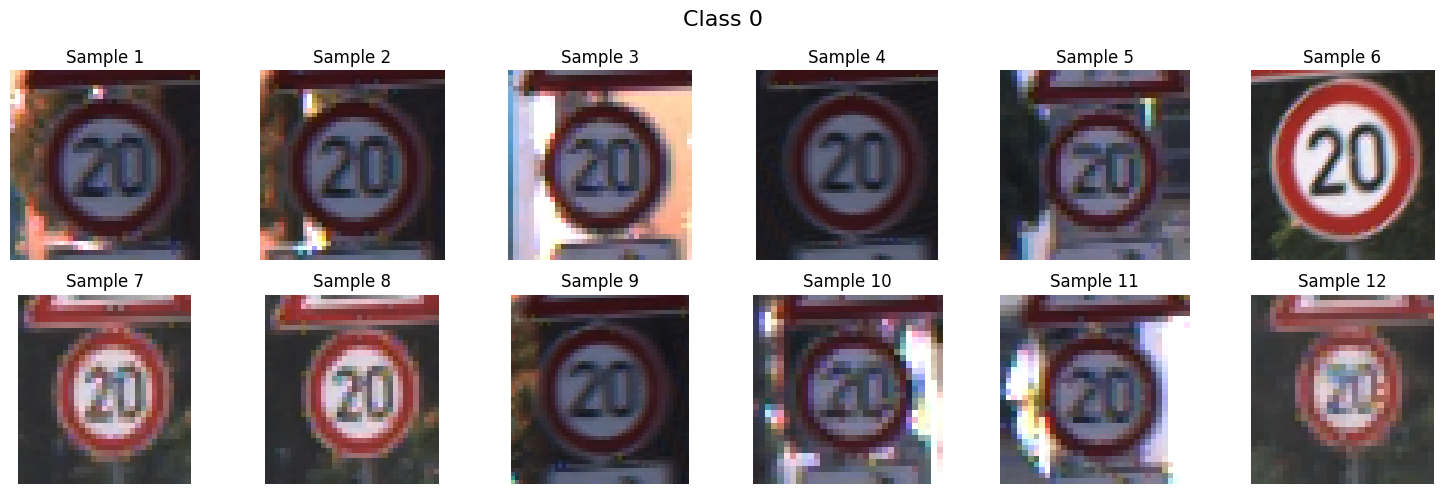

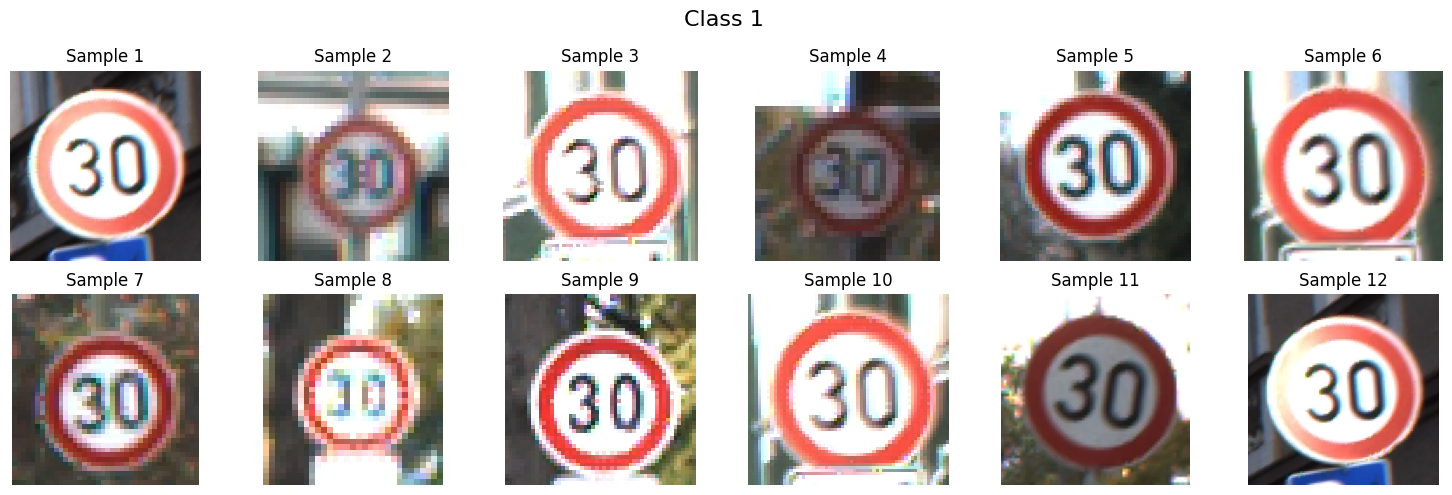

In [23]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

for class_id in first_two_classes:
    class_samples = subset_df[subset_df["ClassId"] == class_id].head(12)

    plt.figure(figsize=(15, 5))
    plt.suptitle(f"Class {class_id}", fontsize=16)

    for i, (_, row) in enumerate(class_samples.iterrows(), 1):
        img_path = os.path.join(attack_data_dir, os.path.basename(row["Path"]))
        img = mpimg.imread(img_path)

        plt.subplot(2, 6, i)
        plt.imshow(img)
        plt.axis('off')
        plt.title(f"Sample {i}")

    plt.tight_layout()
    plt.show()

In [17]:
import shutil
import os

# Define paths (update these!)
attack_data_dir = "/content/Test_subset/Attack_testdata"  # Directory containing images + CSV
output_zip = "/content/Test_subset/Attack_testdata.zip"  # Output ZIP path

# Create ZIP (includes both images and CSV)
shutil.make_archive(output_zip.replace('.zip', ''), 'zip', attack_data_dir)
print(f"ZIP created at: {output_zip}")

ZIP created at: /content/Test_subset/Attack_testdata.zip
